# Tests with Vlasov

In [4]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [5]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import matplotlib as mpl

import lineax

from jaxtyping import ArrayLike, Real, Complex
from tqdm.notebook import tqdm

import sympy as sp
from IPython.display import display_latex

from c1lgkt.jax.analysis.initial_conditions import quasirandom

import operator
import optax

from c1lgkt.jax.analysis.wba import wba_weights

from jax._src.core import ShapeDtypeStruct as ShapeDtypeStruct
from jaxtyping import Array, Inexact, PyTree

In [21]:
# %% Vlasov dynamics

max_steps = 256
decimate = 64
batch_size = 4096

@jax.jit
def drift_vlasov(t, y, args):
    x, p = y
    vlasov_params, wave_params = args
    dxdt = p / vlasov_params.m
    dpdt = vlasov_params.q * vlasov_params.e_field(t, x, wave_params) - vlasov_params.gamma * p
    return dxdt, dpdt

def diffusion_vlasov(t, y, args):
    x, p = y
    vlasov_params, wave_params = args
    dW_x = 0.0
    dW_p = jnp.sqrt(2 * vlasov_params.gamma * vlasov_params.m)
    return lineax.FunctionLinearOperator(lambda v: (jnp.zeros_like(v), dW_p * v), input_structure=ShapeDtypeStruct((batch_size,), jnp.float64))

class WaveParams(NamedTuple):
    # Wave number
    k: Real
    # Frequency
    omega: Real

class HarmonicElectricField(eqx.Module):
    # Amplitude of the electric field
    e0: Real

    def __call__(self, t, x, wave_params: WaveParams):
        # phi = phi0 * cos(omega t - k x), so E = -dphi/dx = -phi0 * k * sin(omega t - k x), div(E) = phi0 * k^2 * cos(omega t - k x) = e0 * k * cos(omega t - k x)
        return -self.e0 * jnp.sin(wave_params.omega * t - wave_params.k * x)

class VlasovParams(NamedTuple):
    # Particle mass
    m: Real
    # Particle charge
    q: Real
    # Damping rate
    gamma: Real
    # Density
    n0: Real
    # Electric field function
    e_field: HarmonicElectricField

In [22]:
# %% Terms related to fluid moments and Poisson equation
@jax.jit
def re_exp(a: Complex, phase: Real[ArrayLike, "..."]) -> Real[ArrayLike, "..."]:
    return jnp.real(a) * jnp.cos(phase) - jnp.imag(a) * jnp.sin(phase)

class HarmonicFluidWeights(eqx.Module):
    n1: Complex
    u1: Complex
    t1: Complex
    q1: Complex
    
    @jax.jit
    def __call__(self, ts: PyTree, ys: PyTree, wave_params: WaveParams):
        x, p = ys
        x0 = x[0,:]
        p0 = p[0,:]
        phase = wave_params.omega * ts[0] - wave_params.k * x0
        p_weights = jnp.exp(re_exp(self.n1, phase) + p0 * re_exp(self.u1, phase) + 0.5 * (p0**2 - 1.0) * re_exp(self.t1, phase) + (p0**3 - 3.0 * p0) * re_exp(self.q1, phase))
        return p_weights / jnp.sum(p_weights)

# Set up weights for WBA and compute the difference from the initial weights
wba_w = wba_weights(max_steps//decimate+1)

tweight0 = jnp.zeros(max_steps//decimate+1)
tweight0 = tweight0.at[0].set(1.0)
tweight1 = wba_w

diff_weights = tweight1 - tweight0

@jax.jit
def compute_fluid_moments(ts: PyTree, ys: PyTree, p_weights: PyTree, t_weights: PyTree, wave_params: WaveParams):
    xs, ps = ys
    phase = wave_params.k * xs - wave_params.omega * ts[:, None]
    weights = p_weights[None,:] * t_weights[:, None]
    cos_weight = weights * jnp.cos(phase) / jnp.pi
    sin_weight = -weights * jnp.sin(phase) / jnp.pi

    n1 = jnp.sum(cos_weight) + 1j* jnp.sum(sin_weight)
    u1 = jnp.sum(cos_weight * ps) + 1j * jnp.sum(sin_weight * ps)
    t1 = jnp.sum(cos_weight * (ps**2)) + 1j * jnp.sum(sin_weight * (ps**2))
    q1 = jnp.sum(cos_weight * (ps**3)) + 1j * jnp.sum(sin_weight * (ps**3))

    return n1, u1, t1, q1

#response1 = compute_fluid_moments(sol.ts, sol.ys, HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0j, u1=0.00j, t1=0.0j), tweight1)
#norm1 = jax.tree_util.tree_map(lambda a: jnp.abs(a)**2, response1)


In [30]:
# %% Objective function

from collections.abc import Sequence


class VlasovProblemInput(eqx.Module):
    """
    Class holding input parameters to the vlasov problem
    """
    m: Real
    q: Real
    gamma: Real
    k_wave: Real
    e0: Real
    n0: Real


class VlasovProblemInnerUnknowns(eqx.Module):
    """
    Class holding unknown parameters to be solved for in the inner problem of the vlasov problem
    """
    n1: Complex
    u1: Complex
    t1: Complex
    q1: Complex

    def to_array(self) -> Array:
        return jnp.array([jnp.real(self.n1), jnp.imag(self.n1), jnp.real(self.u1), jnp.imag(self.u1), jnp.real(self.t1), jnp.imag(self.t1), jnp.real(self.q1), jnp.imag(self.q1)])
    
    @staticmethod
    def from_array(arr: Array) -> VlasovProblemInnerUnknowns:
        return VlasovProblemInnerUnknowns(n1=arr[0] + 1j * arr[1], u1=arr[2] + 1j * arr[3], t1=arr[4] + 1j * arr[5], q1=arr[6] + 1j * arr[7])

class VlasovProblemOuterUnknowns(eqx.Module):
    """
    Class holding unknown parameters to be solved for in the outer problem of the vlasov problem
    """
    omega: Real

    def to_array(self) -> Array:
        return jnp.array([self.omega])
    
    @staticmethod
    def from_array(arr: Array) -> VlasovProblemOuterUnknowns:
        return VlasovProblemOuterUnknowns(omega=arr[0])


@jax.jit
def fn_inner(x, args: tuple[VlasovProblemInput, VlasovProblemOuterUnknowns, diffrax.Solution]):
    vlasov_input, outer_unknowns, sol = args
    inner_unknowns = VlasovProblemInnerUnknowns.from_array(x)

    wave_params = WaveParams(k=vlasov_input.k_wave, omega=outer_unknowns.omega)
    p_weights = HarmonicFluidWeights(n1=inner_unknowns.n1, u1=inner_unknowns.u1, t1=inner_unknowns.t1, q1=inner_unknowns.q1)(sol.ts, sol.ys, wave_params)
    dn, du, dt, dq = compute_fluid_moments(sol.ts, sol.ys, p_weights, diff_weights, wave_params)

    return jnp.array([jnp.real(dn), jnp.imag(dn), jnp.real(du), jnp.imag(du), jnp.real(dt), jnp.imag(dt), jnp.real(dq), jnp.imag(dq)])

@jax.jit
def fn_outer(x, args: tuple[VlasovProblemInput, Array]):
    # Unpack unknowns
    outer_unknowns = VlasovProblemOuterUnknowns.from_array(x)

    # Set up parameters for the Vlasov simulation
    vlasov_input, key = args
    
    field = HarmonicElectricField(e0=vlasov_input.e0)
    vlasov_params = VlasovParams(m=vlasov_input.m, q=vlasov_input.q, gamma=vlasov_input.gamma, n0=vlasov_input.n0, e_field=field)
    wave_params = WaveParams(k=vlasov_input.k_wave, omega=outer_unknowns.omega)
    
    diffrax_args = (vlasov_params, wave_params)

    # Set up initial conditions for the Vlasov simulation
    z1, z2 = quasirandom([[0.0, 2*jnp.pi], [-1.0, 1.0]], batch_size)
    # Random offset
    key, subkey = jax.random.split(key)
    offset = jax.random.uniform(subkey, shape=(2,))
    z1 = (z1 + offset[0]) % (2*jnp.pi)
    z2 = (z2 + offset[1] + 1.0) % 2.0 - 1.0
    p0 = jax.lax.erf_inv(z2)

    t0, t1 = 0.0, 2*jnp.pi/4.0
    dt = (t1 - t0) / max_steps

    y0 = (z1, p0)

    # Set up terms
    bm = diffrax.VirtualBrownianTree(t0, t1, tol=dt/2.0, shape=(batch_size,), key=key)
    drift_term = diffrax.ODETerm(drift_vlasov)
    diffusion_term = diffrax.ControlTerm(diffusion_vlasov, bm)
    terms = diffrax.MultiTerm(drift_term, diffusion_term)

    # Set up solver and saveat
    solver = diffrax.Heun()
    saveat = diffrax.SaveAt(t0=True, t1=True, steps=decimate)

    # Compute samples of Vlasov equation
    sol = diffrax.diffeqsolve(
        terms,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt,
        y0=y0,
        args=diffrax_args,
        saveat=saveat,
        max_steps=max_steps,
    )

    # Compute solution to the inner problem
    solver = optx.Newton(rtol=1e-6, atol=1e-6)
    theta0 = jnp.zeros(8)
    theta_solve = optx.root_find(fn_inner, solver, theta0, args=(vlasov_input, outer_unknowns, sol), adjoint=optx.ImplicitAdjoint())
    inner_sol = VlasovProblemInnerUnknowns.from_array(theta_solve.value)

    # Compute residuals for the outer problem, which in this case is just the real part of the dispersion relation
    p_weights = HarmonicFluidWeights(n1=inner_sol.n1, u1=inner_sol.u1, t1=inner_sol.t1, q1=inner_sol.q1)(sol.ts, sol.ys, wave_params)
    nresp, uresp, tresp, qresp = compute_fluid_moments(sol.ts, sol.ys, p_weights, wba_w, wave_params)
    return jnp.array([vlasov_input.e0 * vlasov_input.k_wave - jnp.real(nresp) * vlasov_input.q * vlasov_input.n0])


def jacrev_and_value(func, argnums: int | Sequence[int] =0):
    def wrapper(*args, **kwargs):
        value = func(*args, **kwargs)
        return value, value
    return jax.jacrev(wrapper, argnums=argnums, has_aux=True)

my_func = jacrev_and_value(fn_outer, argnums=0)
outer_step_fn = jax.jit(my_func)

In [38]:
n0_array = jnp.linspace(1.0, 25.0, 25)

In [39]:
omega_array = np.zeros(25)

for i in range(len(n0_array)):
    # Set up problem
    n0 = n0_array[i]
    print(f"Solving for n0 = {n0}")
    vlasov_input = VlasovProblemInput(m=1.0, q=-1.0, gamma=0.1, k_wave=1.0, e0=1e-3, n0=n0)
    key = jax.random.PRNGKey(0)

    # Initial guess
    theta0 = jnp.array([jnp.sqrt(n0 + 3)])

    # Start optimization
    theta_step = theta0
    theta_step_old = theta_step
    last_loss = jnp.inf
    learning_rate = 0.25
    for k in range(16):
        outer_step = outer_step_fn(theta_step, (vlasov_input, key))
        # Decide whether or not to take the full step or a smaller step based on whether the loss is decreasing
        loss = jnp.abs(outer_step[1][0])
        if loss < 1e-4:
            print(f"Converged with loss {loss}")
            omega_array[i] = theta_step[0]
            break
        elif jnp.abs(outer_step[1][0]) < last_loss:
            last_loss = jnp.abs(outer_step[1][0])
            theta_step_old = theta_step
            if learning_rate < 1.0:
                learning_rate = jnp.minimum(learning_rate * 1.1, 1.0)
        else:
            print(f"Loss increased from {last_loss} to {jnp.abs(outer_step[1][0])}, reducing learning rate")
            learning_rate *= 0.5
            theta_step = theta_step_old

        theta_step = theta_step - learning_rate * outer_step[1] / outer_step[0][0,0]
        print(outer_step)
        print(theta_step)
        print('learning rate:', learning_rate)

Solving for n0 = 1.0
(Array([[0.00072213]], dtype=float64), Array([0.00101561], dtype=float64))
[1.6132403]
learning rate: 0.275
(Array([[0.00279018]], dtype=float64), Array([0.00021006], dtype=float64))
[1.59046602]
learning rate: 0.30250000000000005
(Array([[0.00270246]], dtype=float64), Array([0.00014749], dtype=float64))
[1.57230617]
learning rate: 0.3327500000000001
Converged with loss 9.912038144527246e-05
Solving for n0 = 2.0
(Array([[5.81405742e-05]], dtype=float64), Array([0.00116941], dtype=float64))
[-3.2951633]
learning rate: 0.275
(Array([[0.00018482]], dtype=float64), Array([0.00082916], dtype=float64))
[-4.65223867]
learning rate: 0.30250000000000005
(Array([[0.0005169]], dtype=float64), Array([0.00020888], dtype=float64))
[-4.78670662]
learning rate: 0.3327500000000001
(Array([[0.00030957]], dtype=float64), Array([0.00015204], dtype=float64))
[-4.9664726]
learning rate: 0.36602500000000016
(Array([[-0.00014992]], dtype=float64), Array([0.0001346], dtype=float64))
[-4.60

KeyboardInterrupt: 

In [ ]:
plt.figure()
plt.plot(n0_array, omega_array, label='Computed')
plt.plot(n0_array, np.sqrt(n0_array + 3), label='Theoretical')
plt.xlabel('n0')
plt.ylabel('omega')
plt.legend()

In [31]:
theta0 = jnp.array([4.0])
vlasov_input = VlasovProblemInput(m=1.0, q=-1.0, gamma=0.1, k_wave=1.0, e0=1e-3, n0=13.0)
key = jax.random.PRNGKey(0)



In [28]:
theta_step = theta0

(Array([[0.00898305]], dtype=float64), Array([-6.93363409e-05], dtype=float64))
[4.32057212]
learning rate: 0.275
(Array([[0.00902844]], dtype=float64), Array([-5.02206699e-05], dtype=float64))
[4.32225478]
learning rate: 0.30250000000000005
(Array([[0.00906437]], dtype=float64), Array([-3.49986833e-05], dtype=float64))
[4.32353957]
learning rate: 0.3327500000000001
(Array([[0.00909177]], dtype=float64), Array([-2.33352642e-05], dtype=float64))
[4.32447902]
learning rate: 0.36602500000000016
(Array([[0.00911179]], dtype=float64), Array([-1.47845681e-05], dtype=float64))
[4.32513231]
learning rate: 0.4026275000000002
(Array([[0.00912571]], dtype=float64), Array([-8.82734864e-06], dtype=float64))
[4.32556072]
learning rate: 0.44289025000000026
(Array([[0.00913483]], dtype=float64), Array([-4.915848e-06], dtype=float64))
[4.3258229]
learning rate: 0.48717927500000036


KeyboardInterrupt: 

In [25]:
theta_step

Array([2.05731819], dtype=float64)

In [4]:
def display_log_weights():
    dn, n0, v, du, u0, dt, t0, eps = sp.symbols('dn n0 v du u0 dt t0 epsilon')
    maxwellian = (n0+eps*dn) * sp.sqrt(1 / (2 * sp.pi * (t0 + eps*dt))) * sp.exp(- (v - eps*du)**2 / (2 * (t0 + eps*dt)))
    display_latex(sp.collect(sp.expand(sp.diff(sp.log(maxwellian), eps).subs(eps, 0)), [dn, du, dt]))

display_log_weights()

In [24]:

# ── Inner residual:  0 = f(y, θ)  ───────────────────────────────────────────
# y is fast to compute given θ; e.g. an algebraic condition on top of an ODE state
def f_inner(y, args):
    theta = args
    # e.g. some ODE-derived quantity minus y, or an implicit algebraic relation
    # (replace with your actual computation)
    return y**3 + theta * y - 1.0   # placeholder

# ── Outer residual:  0 = g(y*(θ), θ)  ───────────────────────────────────────
# This calls the inner solve as a black box
def g_outer(theta, args):
    # --- solve the inner problem for y*(θ) ---
    y0 = jnp.array(1.0)  # initial guess for y
    inner_sol = optx.root_find(
        f_inner,
        optx.Newton(rtol=1e-8, atol=1e-8),
        y0,
        args=theta,
        adjoint=optx.ImplicitAdjoint(),  # IFT handles dy*/dθ
    )
    y_star = inner_sol.value

    # --- evaluate outer residual at y*(θ) ---
    # (replace with your actual g)
    return y_star - 1.1   # placeholder: solve for θ s.t. y*(θ)·θ = 2

# ── Solve the outer problem with Newton  ─────────────────────────────────────
theta0 = jnp.array(1.5)  # initial guess for θ

outer_sol = optx.root_find(
    g_outer,
    optx.Newton(rtol=1e-6, atol=1e-6),
    theta0,
    args=None,
)
theta_star = outer_sol.value
print(f"θ* = {theta_star:.6f}")

θ* = -0.300909


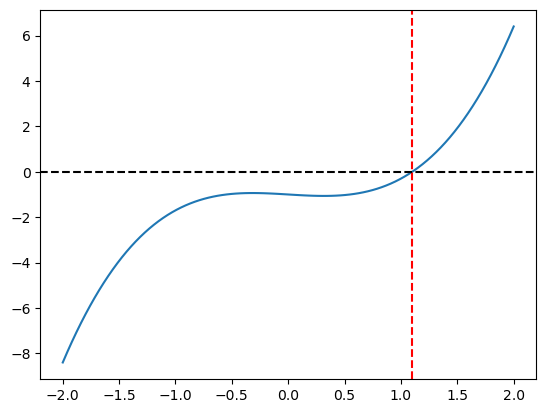

In [27]:
plt.figure()
yplot = np.linspace(-2, 2, 100)
plt.plot(yplot, yplot**3 + theta_star * yplot - 1.0)  # plot f_inner(y, θ*) to verify root at y*(θ*)
plt.axvline(x=1.1, color='red', linestyle='--', label='y* = 1.1')
plt.axhline(0, color='black', linestyle='--')

In [7]:
@jax.jit
def fn_root(x, args):
    n1 = x[0] + 1j * x[1]
    u1 = x[2] + 1j * x[3]
    t1 = x[4] + 1j * x[5]

    weights = HarmonicFluidWeights(k=k_wave, omega=omega, n1=n1, u1=u1, t1=t1)
    dn, du, dt = compute_fluid_moments(sol.ts, sol.ys, weights, diff_weights)
    return jnp.array([jnp.real(dn), jnp.imag(dn), jnp.real(du), jnp.imag(du), jnp.real(dt), jnp.imag(dt)])


In [8]:
solver = optx.Newton(rtol=1e-3, atol=1e-3)
theta0 = jnp.zeros(6)
theta_sol = optx.root_find(fn_root, solver, theta0)

In [9]:
@jax.jit
def fn_eval(tweight):
    n1 = theta_sol.value[0] + 1j * theta_sol.value[1]
    u1 = theta_sol.value[2] + 1j * theta_sol.value[3]
    t1 = theta_sol.value[4] + 1j * theta_sol.value[5]

    weights = HarmonicFluidWeights(k=k_wave, omega=omega, n1=n1, u1=u1, t1=t1)
    weights0 = HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0j, u1=0.00j, t1=0.0j)
    r1 = compute_fluid_moments(sol.ts, sol.ys, weights, tweight)
    r2 = compute_fluid_moments(sol.ts, sol.ys, weights0, tweight)
    return r1, r2

all_weights = jnp.eye(len(sol.ts))
nresp = np.zeros(len(sol.ts), dtype=np.complex128)
uresp = np.zeros(len(sol.ts), dtype=np.complex128)
tresp = np.zeros(len(sol.ts), dtype=np.complex128)
nresp0 = np.zeros(len(sol.ts), dtype=np.complex128)
uresp0 = np.zeros(len(sol.ts), dtype=np.complex128)
tresp0 = np.zeros(len(sol.ts), dtype=np.complex128)

for k in tqdm(range(len(sol.ts))):
    r1, r2 = fn_eval(all_weights[k])
    nresp[k] = r1[0]
    uresp[k] = r1[1]
    tresp[k] = r1[2]
    nresp0[k] = r2[0]
    uresp0[k] = r2[1]
    tresp0[k] = r2[2]

  0%|          | 0/1025 [00:00<?, ?it/s]

In [10]:
np.average(np.sin(y0[0]))

np.float64(1.5017857722627388e-05)

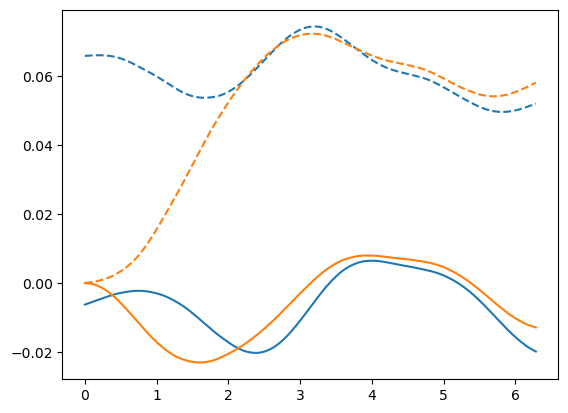

In [30]:
plt.figure()
plt.plot(sol.ts, jnp.real(nresp), c='tab:blue')
plt.plot(sol.ts, jnp.imag(nresp), c='tab:blue', ls='--')
plt.plot(sol.ts, jnp.real(nresp0), c='tab:orange')
plt.plot(sol.ts, jnp.imag(nresp0), c='tab:orange', ls='--')

In [145]:
fn_root(theta_sol.value, None)

Array([ 1.50733835e-11,  1.74317678e-09, -6.16965364e-10, -3.92869322e-09,
        2.34837348e-09,  7.96615403e-09], dtype=float64)

In [ ]:
weights_test = HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0+0j, u1=0.0j, t1=0.0j)

print(compute_fluid_moments(sol.ts, sol.ys, weights_test, tweight0))
print(compute_fluid_moments(sol.ts, sol.ys, weights_test, tweight1))
print(compute_fluid_moments(sol.ts, sol.ys, weights_test, diff_weights))

(Array(0.00069407+0.01553311j, dtype=complex128), Array(-0.02801665+0.01605608j, dtype=complex128), Array(-0.00638184+0.00800957j, dtype=complex128))
(Array(-0.00167383+0.02943288j, dtype=complex128), Array(-0.00899592+0.04052633j, dtype=complex128), Array(-0.04725219+0.01168404j, dtype=complex128))
(Array(0.00713736-0.02211234j, dtype=complex128), Array(0.0055041-0.00849764j, dtype=complex128), Array(0.02730641-0.00819039j, dtype=complex128))


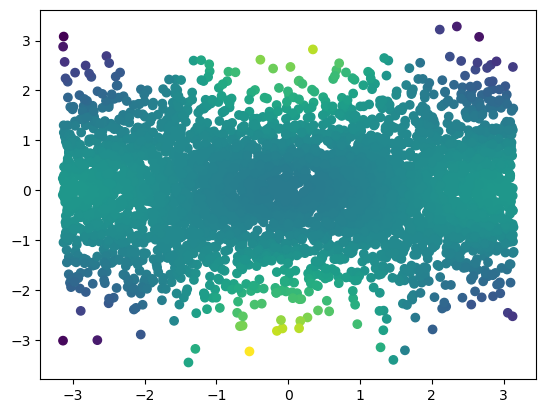

In [ ]:
plt.figure()
p_weights = jnp.exp(HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0, u1=0.00j, t1=0.04)(t=t0, y=y0))
plt.scatter(y0[0], y0[1], c=p_weights)

In [123]:

theta0 = (0.0j, 0.0j, 0.0j)
solver = optax.adam(learning_rate=1e-3)
opt_state = solver.init(theta0)
for _ in range(30):
    loss, grads = jax.value_and_grad(fn_objective)(theta0)
    updates, opt_state = solver.update(grads, opt_state)
    theta0 = optax.apply_updates(theta0, updates)
    print(f"Step {_}: loss = {loss}")

Step 0: loss = 1.0237228022238005
Step 1: loss = 1.026355161354592
Step 2: loss = 1.0290300238172145
Step 3: loss = 1.0317480772818288
Step 4: loss = 1.034510015632487
Step 5: loss = 1.0373165380960616
Step 6: loss = 1.0401683483799993
Step 7: loss = 1.043066153826174
Step 8: loss = 1.0460106645877485
Step 9: loss = 1.0490025928355187
Step 10: loss = 1.0520426519998003
Step 11: loss = 1.055131556053195
Step 12: loss = 1.058270018839031
Step 13: loss = 1.0614587534495565
Step 14: loss = 1.0646984716572485
Step 15: loss = 1.0679898834018533
Step 16: loss = 1.0713336963350886
Step 17: loss = 1.0747306154241236
Step 18: loss = 1.0781813426144256
Step 19: loss = 1.0816865765517019
Step 20: loss = 1.0852470123622335
Step 21: loss = 1.088863341490287
Step 22: loss = 1.092536251590701
Step 23: loss = 1.0962664264745021
Step 24: loss = 1.1000545461048792
Step 25: loss = 1.1039012866405997
Step 26: loss = 1.1078073205237413
Step 27: loss = 1.1117733166084214
Step 28: loss = 1.1157999403270504
St

In [ ]:
n1 = theta_sol.value[0] + 1j * theta_sol.value[1]
u1 = theta_sol.value[2] + 1j * theta_sol.value[3]
t1 = theta_sol.value[4] + 1j * theta_sol.value[5]

print(compute_fluid_moments(sol.ts, sol.ys, HarmonicFluidWeights(k=k_wave, omega=omega, n1=n1, u1=u1, t1=t1), tweight0))
print(compute_fluid_moments(sol.ts, sol.ys, HarmonicFluidWeights(k=k_wave, omega=omega, n1=n1, u1=u1, t1=t1), tweight1))

print(compute_fluid_moments(sol.ts, sol.ys, HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0j, u1=0.0j, t1=0.0j), tweight0))
print(compute_fluid_moments(sol.ts, sol.ys, HarmonicFluidWeights(k=k_wave, omega=omega, n1=0.0j, u1=0.0j, t1=0.0j), tweight1))

(Array(-0.00165321+0.02934318j, dtype=complex128), Array(-0.00898782+0.0397902j, dtype=complex128), Array(-0.04742793+0.01278108j, dtype=complex128))
(Array(-0.00165319+0.02934317j, dtype=complex128), Array(-0.00898779+0.03979017j, dtype=complex128), Array(-0.0474278+0.01278107j, dtype=complex128))
(Array(0.00069407+0.01553311j, dtype=complex128), Array(-0.02801665+0.01605608j, dtype=complex128), Array(-0.00638184+0.00800957j, dtype=complex128))
(Array(-0.00167383+0.02943288j, dtype=complex128), Array(-0.00899592+0.04052633j, dtype=complex128), Array(-0.04725219+0.01168404j, dtype=complex128))


In [ ]:
xs, ps = sol.ys
xs_frame = k_wave * xs - omega * sol.ts[:, None]
hist, bin_edges = jnp.histogram(jnp.mod(xs_frame.ravel()+2*jnp.pi/32, 2*jnp.pi)-2*jnp.pi/32, bins=32, range=(0 - 2*jnp.pi/32, 2*jnp.pi - 2*jnp.pi/32), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

In [20]:
np.sum(hist * np.diff(bin_edges))

Array(1., dtype=float64)

In [37]:
a1 = jnp.mean(jnp.cos(xs_frame.ravel())) / (jnp.pi)
b1 = jnp.mean(jnp.sin(xs_frame.ravel())) / (jnp.pi)

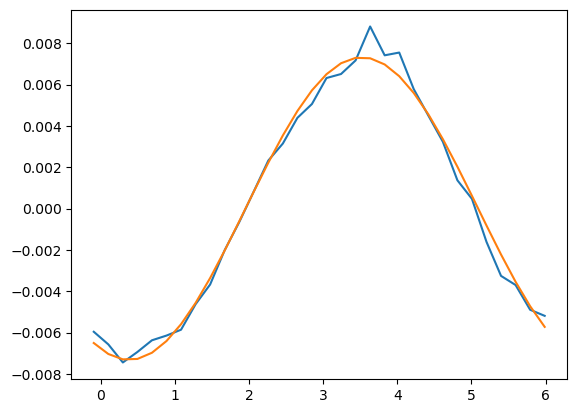

In [38]:
plt.figure()
plt.plot(bin_centers, hist - 1/(2*jnp.pi), label='Histogram')
plt.plot(bin_centers, a1 * jnp.cos(bin_centers) + b1 * jnp.sin(bin_centers), label='Fourier fit')

In [34]:
a1, b1

(Array(-0.00728349, dtype=float64), Array(-0.00251566, dtype=float64))

In [28]:
b1

Array(-0.0243712, dtype=float64)